<table>
    <tr>
        <td><img src="https://raw.githubusercontent.com/Fabian830348/Bases_Datos/refs/heads/master/logo_ECI.png" width="300"/></td>
        <td>&nbsp;</td>
        <td>
            <h1 style="font-size:200%;color:blue;text-align:center">    <FONT COLOR="blue">  Redes Neuronales </p> Ejemplos Pytorch </p>     </h1></td>         
        <td>
            <tp><p style="font-size:99%;text-align:center">Machine Learning 1</p></tp>
            <tp><p style="font-size:115%;text-align:center">Pregrado MACC 2026-1</p></tp>
            <tp><p style="font-size:115%;text-align:center">Prof. Fabián Sánchez</p></tp>
        </td>
    </tr>
</table>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Primero vamos a cargar las librerías

pisble pregunta que es bce binari cross entropi

In [2]:
# Manipulación de data.frames
import pandas as pd
import numpy as np

# Librerías para Gráficos
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Librerías para datos de entrenamiento y prueba
from sklearn.model_selection    import train_test_split

# Para preprocesamiento
from sklearn.preprocessing      import StandardScaler, MinMaxScaler
from sklearn.preprocessing      import LabelEncoder, OneHotEncoder
from sklearn.compose            import ColumnTransformer
from sklearn.pipeline           import Pipeline

# Para modelos de clasificación
from sklearn.neighbors          import KNeighborsClassifier
from sklearn.linear_model       import LogisticRegression
from sklearn.tree               import DecisionTreeClassifier
from sklearn.svm                import SVC
from sklearn.ensemble           import RandomForestClassifier

# Métricas de evaluación clasificación
from sklearn.metrics            import confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.metrics            import accuracy_score, precision_score, recall_score, f1_score
from imblearn.metrics           import specificity_score

# Métricas para regresión
from sklearn                     import metrics
from sklearn.metrics             import mean_squared_error, r2_score, mean_absolute_error

# para hacer la curva ROC
from sklearn.metrics            import roc_auc_score
from sklearn.metrics            import roc_curve

# Optimización de hiperparámetros
from sklearn.model_selection    import GridSearchCV

import time

#librerías asociadas a Pytorch
import torch
import torch.nn                  as nn
import torch.nn.functional       as F

import torchvision
import torch.utils.data
import torchvision.transforms    as transform

from torch.utils.data            import Dataset, DataLoader


# Para ignorar los warnings
import warnings
warnings.filterwarnings("ignore")

# <FONT SIZE=5 COLOR="purple"> 1. Ejemplo  Clasificación-Tarjetas de Crédito</FONT>

***Objetivo del ejercicio***. Aplicar el modelo de clasificación ***KNN-Reglog-Árboles*** para determinar cuando se aprueba a un cliente una tarjeta de crédito o no, dependiendo de las otras variables.

***Contexto de los datos***

Este ejercicio se basa en un conjunto de datos que se publicó originalmente junto con la quinta edición del libro *Análisis Econométrico* de William Greene.

Este libro tiene datos de tarjetas de crédito que se componen de una variable objetivo que es de naturaleza binaria (1 si se aprueba la solicitud de tarjeta de crédito, 0 si no) y algunas variables independientes sobre la demografía y el historial crediticio de los titulares de tarjetas de crédito.

Los datos para este trabajo están en *kaggle* en la siguiente *url*.

https://www.kaggle.com/datasets/dansbecker/aer-credit-card-data?select=AER_credit_card_data.csv

Sin embargo, se anexan los datos como ***credict3*** y este trabajo se va a desarrollar con esta base.

```python
url = "https://raw.githubusercontent.com/Fabian830348/Bases_Datos/master/credit3.csv"
```

Cada fila representa una solicitud de tarjeta de crédito, cada columna contiene los atributos del solicitante:

- *tarjeta*: variable ficticia, 1 si se aprueba la solicitud de tarjeta de crédito, 0 si no

- *informes*: número de informes despectivos importantes.

- *edad*: Edad n años más doceavos de un año.

- *ingreso*: ingreso anual (dividido por 10,000).

- *participación*: relación entre el gasto mensual de la tarjeta de crédito y el ingreso anual.

- *gasto*: gasto medio mensual con tarjeta de crédito.

- *propietario*: 1 si es dueño de su casa, 0 si alquila.

- *selfemp*: 1 si es autónomo, 0 si no.

- *dependientes*: 1 + número de dependientes.

- *meses*: Meses viviendo en la dirección actual.

- *majorcards*: número de las principales tarjetas de crédito que se tienen.

- activo: Número de cuentas de crédito activas.

Según Greene (2003, p. 952) los dependientes equivalen a 1 + número de dependientes. Eso se describe arriba. Los autores del paquete “AER” en R creen que es el número de dependientes.

Algunas precisiones sobre las variables

- *Los informes promedio* (es decir, el número promedio de informes despectivos importantes) de los solicitantes que fueron aprobados es menor que el de los solicitantes que no fueron aprobados.

- *El ingreso promedio* (es decir, el ingreso anual promedio dividido por 10,000) de los solicitantes que fueron aprobados es más alto que el de los solicitantes que no fueron aprobados.

- *La participación promedio* (es decir, la relación promedio entre el gasto mensual de la tarjeta de crédito y el ingreso anual) de los solicitantes que fueron aprobados es más alta que la de los solicitantes que no fueron aprobados.

- *El gasto promedio* (es decir, el gasto mensual promedio con tarjeta de crédito) de los solicitantes que fueron aprobados es más alto que el de los solicitantes que no fueron aprobados.

- *El promedio de dependientes*(es decir, el número promedio de dependientes) de los solicitantes que fueron aprobados es menor que el de los solicitantes que no fueron aprobados.

- *El promedio de tarjetas principales (es decir, el número promedio de las principales tarjetas de crédito) de los solicitantes que fueron aprobados es más alto que el de los solicitantes que no fueron aprobados.

## <FONT SIZE=4 COLOR="blue"> 1.1 Carga y exploración rápida de los datos</FONT>

In [3]:
# cargar los datos que están la dirección del github
url = "https://raw.githubusercontent.com/Fabian830348/Bases_Datos/master/datos_credito.csv"
credito = pd.read_csv(url, na_values=[" "])

na.values : si hay espacios (blanco) lo identifica como dato faltante NaN (NA)

In [4]:
# revisamos los primeros datos
credito.head()

,card,reports,age,income,share,expenditure,owner,selfemp,dependents,months,majorcards,active
0,1,0,37.66667,4.5200,0.033270,124.983300,1,0,3,54,1,12
1,1,0,33.25000,2.4200,0.005217,9.854167,0,0,3,34,1,13
2,1,0,33.66667,4.5000,0.004156,15.000000,1,0,4,58,1,5
3,1,0,30.50000,2.5400,0.065214,137.869200,0,0,0,25,1,7
4,1,0,32.16667,9.7867,0.067051,546.503300,1,0,2,64,1,5


In [5]:
# nombre de las variables
credito.columns

Index(['card', 'reports', 'age', 'income', 'share', 'expenditure', 'owner',
       'selfemp', 'dependents', 'months', 'majorcards', 'active'],
      dtype='object')

In [6]:
# información de las variables
credito.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1310 entries, 0 to 1309
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   card         1310 non-null   int64  
 1   reports      1310 non-null   int64  
 2   age          1310 non-null   float64
 3   income       1310 non-null   float64
 4   share        1310 non-null   float64
 5   expenditure  1310 non-null   float64
 6   owner        1310 non-null   int64  
 7   selfemp      1310 non-null   int64  
 8   dependents   1310 non-null   int64  
 9   months       1310 non-null   int64  
 10  majorcards   1310 non-null   int64  
 11  active       1310 non-null   int64  
dtypes: float64(4), int64(8)
memory usage: 122.9 KB


In [7]:
# revisamos los valores de la variable card
# credit.card // credit["card"]
credito.card.value_counts()

,count
card,
1,1016
0,294


En este ejemplo debemos tener en cuenta que hay dos tipos de variables.

- Continuas (numéricas)

- Categóricas (atributos)

In [8]:
#variable objetivo
y = credito["card"]
# variables predictoras
X = credito.drop("card", axis=1)

# dividir en los tres conjuntos
# 1. Dividimos en entrenamiento (60%) y el otro (40%) lo denominamos temporal ya que se va a volver a dividir
X_train, X_temp, y_train, y_temp = train_test_split(X,                        # variables predictoras
                                                    y,                        # variable de respuesta
                                                    random_state = 0,         # semilla para que al ejecutar siempre de igual
                                                    stratify=y,               # estratificamos con respecto a y (asegura que se mantenga la proporción de clases en y)
                                                    test_size = 0.4)          # tamaño del conjunto de prueba

X_val, X_test, y_val, y_test = train_test_split(X_temp,                       # variables predictoras
                                                y_temp,                       # variable de respuesta
                                                random_state = 0,             # semilla para que al ejecutar siempre de igual
                                                stratify=y_temp,              # estratificamos con respecto a y_temp
                                                test_size = 0.5)              # tamaño del conjunto de prueba

# aca son tres porque las redes neuronales funcionan por iteracion
# variables numéricas de predicción
variables_num = credito.drop(["card","owner","selfemp"], axis =1).columns
variables_num

# variables categóricas de predicción (yes/no)
variables_cat = ["owner", "selfemp"]
variables_cat

#si todas mis vrairbles son numericas puedo usar el satandar scaler para escalar los datos pero cuando hay varibales categoricas con numericas las categoricas no se escalan
#entonces definimos las numericas y categoricas y utilizamos el column trasnform y eso hace que escale las numericas y las categoricas no las toque
# Definitmos el preprocesador de escalamiento
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), variables_num),
    ('cat', "passthrough", variables_cat) #passthrough
])

# aplicamos el preprocesador

X_train_s = preprocessor.fit_transform(X_train)
X_val_s = preprocessor.transform(X_val)
X_test_s = preprocessor.transform(X_test)

## <FONT SIZE=4 COLOR="blue"> 1.2 Código en Pytorch</FONT>

In [9]:
# clase para convertir a tensores adems permite calcular la longitud de estos y centrar los elementos de estos y se tuiliza una clase para que guarde la informacion
class CreditoDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y.to_numpy(), dtype=torch.float32).view(-1, 1)  # (N,1)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = CreditoDataset(X_train_s, y_train)
val_dataset = CreditoDataset(X_val_s, y_val)
test_dataset = CreditoDataset(X_test_s, y_test)

# dataLoader es algo que crea lotes los parte en pedasitos pasa el modelo por pedasos que se definen y shuffle es para que revuelva para que no siempre de lo mismo ya que se vuelve
#muy aleatorio
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# clase del modelo es la estructura y arquitectura del modelo es la clase que define el modelo cuantas entras cuantas salen etc
class CreditoModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(11, 32),    # 11 features -> 32 neuronas
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 1)     # salida 1 logit
        )

    def forward(self, x):
        return self.net(x)

#MSE error cuadratico que se utiliza para la de clasificaicon que no son binarias binari cross entropi para busqueda de dos

model = CreditoModel()

# optimizadores Adam es un metodo de optimizacion
criterion = nn.BCEWithLogitsLoss() #esto hay que cambiarlo si es binaria BCEW (binari crooss entropi whit logits loss)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# entrenamiento
num_epochs = 100

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0

    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * X_batch.size(0)

    epoch_loss = running_loss / len(train_loader.dataset)

    # ---- evaluación ----
    model.eval()
    all_preds = []
    all_targets = []
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            logits = model(X_batch)
            probs = torch.sigmoid(logits)
            preds = (probs >= 0.5).float()
            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(y_batch.cpu().numpy())

    acc = accuracy_score(all_targets, all_preds)
    print(f"Epoch {epoch+1}/{num_epochs} - loss: {epoch_loss:.4f} - acc: {acc:.4f}")

Epoch 1/100 - loss: 0.6915 - acc: 0.7557
Epoch 2/100 - loss: 0.6221 - acc: 0.7786
Epoch 3/100 - loss: 0.5276 - acc: 0.8015
Epoch 4/100 - loss: 0.4413 - acc: 0.8397
Epoch 5/100 - loss: 0.3719 - acc: 0.8779
Epoch 6/100 - loss: 0.3177 - acc: 0.9008
Epoch 7/100 - loss: 0.2766 - acc: 0.9198
Epoch 8/100 - loss: 0.2482 - acc: 0.9237
Epoch 9/100 - loss: 0.2277 - acc: 0.9237
Epoch 10/100 - loss: 0.2120 - acc: 0.9313
Epoch 11/100 - loss: 0.2004 - acc: 0.9313
Epoch 12/100 - loss: 0.1912 - acc: 0.9313
Epoch 13/100 - loss: 0.1856 - acc: 0.9313
Epoch 14/100 - loss: 0.1780 - acc: 0.9351
Epoch 15/100 - loss: 0.1724 - acc: 0.9351
Epoch 16/100 - loss: 0.1677 - acc: 0.9351
Epoch 17/100 - loss: 0.1634 - acc: 0.9389
Epoch 18/100 - loss: 0.1592 - acc: 0.9351
Epoch 19/100 - loss: 0.1557 - acc: 0.9351
Epoch 20/100 - loss: 0.1525 - acc: 0.9389
Epoch 21/100 - loss: 0.1489 - acc: 0.9389
Epoch 22/100 - loss: 0.1467 - acc: 0.9351
Epoch 23/100 - loss: 0.1433 - acc: 0.9389
Epoch 24/100 - loss: 0.1395 - acc: 0.9427
E

Evaluación

In [10]:
model.eval()
all_preds, all_targets = [], []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        logits = model(X_batch)
        probs = torch.sigmoid(logits)
        preds = (probs >= 0.5).float()
        all_preds.extend(preds.cpu().numpy())
        all_targets.extend(y_batch.cpu().numpy())
#convertir false y true se llama coersion cuando se cambia el tipo de dato en este caso 0 a 1
final_acc = accuracy_score(all_targets, all_preds)
print(f"Final test accuracy: {final_acc:.4f}")

Final test accuracy: 0.9198


Text(0.5, 23.52222222222222, 'Predicciones')

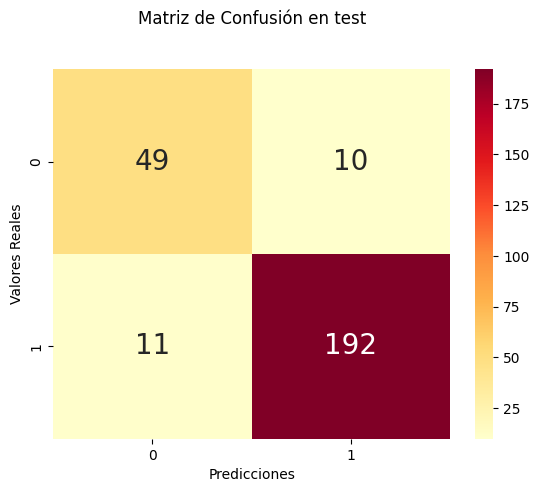

In [11]:
cm = confusion_matrix(all_targets, all_preds)
p = sns.heatmap(pd.DataFrame(cm),                    # data.frame
                annot=True,                          # colocar números de las cajitas
                annot_kws = {'size':20},             # tamaño de la letra
                cmap="YlOrRd",                       # color de la letra 'Pastel1', 'Pastel1_r', 'Pastel2', 'Pastel2_r', 'PiYG', 'PiYG_r', 'PuBu'
                fmt='g')                             # para que salgan los número no : notación científica
plt.title('Matriz de Confusión en test', y=1.1)
plt.ylabel('Valores Reales')
plt.xlabel('Predicciones')

In [12]:
#accuracy score
# nombre de las métricas
metrics=["accuracy", "recall" , "specificidad", "precision", "f1"]
# valores
values = [accuracy_score(all_targets, all_preds),
          recall_score(all_targets, all_preds),
          specificity_score(all_targets, all_preds),
          precision_score(all_targets, all_preds),
          f1_score(all_targets, all_preds)]
pd.DataFrame({"metrics": metrics , "values" : values})

,metrics,values
0,accuracy,0.919847
1,recall,0.945813
2,specificidad,0.830508
3,precision,0.950495
4,f1,0.948148


In [13]:
# evaluar con el classification report
print(classification_report(all_targets, all_preds, digits = 4))


              precision    recall  f1-score   support

         0.0     0.8167    0.8305    0.8235        59
         1.0     0.9505    0.9458    0.9481       203

    accuracy                         0.9198       262
   macro avg     0.8836    0.8882    0.8858       262
weighted avg     0.9204    0.9198    0.9201       262



# <FONT SIZE=5 COLOR="purple"> 2. Ejemplo  Regresión- Predicción de Ventas</FONT>

Vamos a considerar los siguientes datos relacionados con la inversión en publicidad en diferentes medios y las ventas.

El objetivo es hacer un modelo de regresión lineal múltiple para predecir las ventas en función de las variables de pauta publicitaria en diferentes medios.

Se describen las variables independientes: TV, Radio Newpaper y la variable dependiente Sales.

Valor de etiqueta o variable objetivo dependiente(ventas): que significa el volumen de ventas del producto correspondiente

Las variables independientes: (TV, Radio, Periódico, WEB):

TV: para un solo producto en un mercado determinado, el costo de la publicidad en TV (en miles) Radio: costos de publicidad invertidos en medios de difusión Periódico: costos publicitarios para medios periodísticos.

## <FONT SIZE=4 COLOR="blue"> 2.1 Carga y exploración rápida de los datos</FONT>

In [14]:
ventas = pd.read_csv("https://raw.githubusercontent.com/Fabian830348/Bases_Datos/refs/heads/master/ventas.csv", sep = ";" , decimal = "," )
ventas

,Unnamed: 0,Newspaper,TV,Radio,Web,Sales
0,0,46.0,204.1,32.9,245.774960,19.0
1,1,52.9,195.4,47.7,148.095134,22.4
2,2,114.0,67.8,36.6,202.638903,12.5
3,3,55.8,281.4,39.6,41.755313,24.4
4,4,18.3,69.2,20.5,210.489910,11.3
...,...,...,...,...,...,...
195,195,13.8,38.2,3.7,248.841073,7.6
196,196,8.1,94.2,4.9,118.041856,9.7
197,197,6.4,177.0,9.3,213.274671,12.8
198,198,66.2,283.6,42.0,237.498064,25.5


In [15]:
# eliminar la primera columna
ventas = ventas.drop(ventas.columns[0],
                     axis=1)
# axis = 1 : eliminar columnas

In [16]:
ventas.head()

,Newspaper,TV,Radio,Web,Sales
0,46.0,204.1,32.9,245.774960,19.0
1,52.9,195.4,47.7,148.095134,22.4
2,114.0,67.8,36.6,202.638903,12.5
3,55.8,281.4,39.6,41.755313,24.4
4,18.3,69.2,20.5,210.489910,11.3


Primero, seleccionamos las variables predictoras y la variable objetivo

In [17]:
# variable objetivo
y = ventas['Sales'].values
# variables predictoras
X = ventas.drop('Sales', axis=1).values

In [21]:
# Vamos a dividir en tres conjuntos: train, validation y test.
X_temp, X_test, y_temp, y_test = train_test_split(X,
                                                  y,
                                                  test_size=0.4,
                                                  random_state=42)

# ahora X_temp (80%) lo partimos en 60% train y 20% val
X_train, X_val, y_train, y_val = train_test_split(X_temp,
                                                  y_temp,
                                                  test_size=0.5,
                                                  random_state=42)
# queda 60/20/20

In [22]:
# ahora escalamos los datos
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

## <FONT SIZE=4 COLOR="blue"> 2.2 Modelo en Pytorch </FONT>

In [23]:
# clase para convertir a tensores
class VentasDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32).view(-1, 1)  # (N,1)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = VentasDataset(X_train, y_train)
val_dataset = VentasDataset(X_val, y_val)
test_dataset = VentasDataset(X_test, y_test)

# dataLoader
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# clase del modelo
class VentasModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(4, 16),    # 4 features -> 16 neuronas
            nn.ReLU(),
            nn.Linear(16, 8),
            nn.ReLU(),
            nn.Linear(8, 1)     # salida 1 logit
        )

    def forward(self, x):
        return self.net(x)

model = VentasModel()

# optimizadores para regresión
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# entrenamiento
num_epochs = 200

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0

    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * X_batch.size(0)

    epoch_loss = running_loss / len(train_loader.dataset)

    # ---- evaluación ----
    model.eval()
    all_preds = []
    all_targets = []
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            preds = model(X_batch)
            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(y_batch.cpu().numpy())

    mse = mean_squared_error(all_targets, all_preds)
    mae = mean_absolute_error(all_targets, all_preds) # es el error absoluto medio
    r2 = r2_score(all_targets, all_preds)
    print(f"Epoch {epoch+1}/{num_epochs} - loss: {epoch_loss:.4f} - MSE: {mse:.4f} - R2: {r2:.4f}")

Epoch 1/200 - loss: 236.5155 - MSE: 250.5050 - R2: -7.8767
Epoch 2/200 - loss: 236.1715 - MSE: 250.1589 - R2: -7.8644
Epoch 3/200 - loss: 235.8202 - MSE: 249.8009 - R2: -7.8518
Epoch 4/200 - loss: 235.4772 - MSE: 249.4262 - R2: -7.8385
Epoch 5/200 - loss: 235.1171 - MSE: 249.0368 - R2: -7.8247
Epoch 6/200 - loss: 234.7651 - MSE: 248.6407 - R2: -7.8106
Epoch 7/200 - loss: 234.3914 - MSE: 248.2339 - R2: -7.7962
Epoch 8/200 - loss: 233.9997 - MSE: 247.8152 - R2: -7.7814
Epoch 9/200 - loss: 233.5995 - MSE: 247.3803 - R2: -7.7660
Epoch 10/200 - loss: 233.1784 - MSE: 246.9348 - R2: -7.7502
Epoch 11/200 - loss: 232.7599 - MSE: 246.4751 - R2: -7.7339
Epoch 12/200 - loss: 232.3234 - MSE: 246.0019 - R2: -7.7171
Epoch 13/200 - loss: 231.8529 - MSE: 245.5076 - R2: -7.6996
Epoch 14/200 - loss: 231.3838 - MSE: 244.9915 - R2: -7.6813
Epoch 15/200 - loss: 230.8751 - MSE: 244.4627 - R2: -7.6626
Epoch 16/200 - loss: 230.3910 - MSE: 243.9179 - R2: -7.6433
Epoch 17/200 - loss: 229.8711 - MSE: 243.3584 - R

In [24]:
model.eval()
all_preds, all_targets = [], []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        preds =  model(X_batch)
        all_preds.extend(preds.cpu().numpy())
        all_targets.extend(y_batch.cpu().numpy())

final_mse = mean_squared_error(all_targets, all_preds)
final_mae = mean_absolute_error(all_targets, all_preds)
final_r2 = r2_score(all_targets, all_preds)
print(f"Test MSE: {final_mse:.4f} - MAE: {final_mae:.4f} - R2: {final_r2:.4f}")

Test MSE: 10.9028 - MAE: 2.5051 - R2: 0.5551


In [31]:
ventas.Sales.describe()

,Sales
count,200.000000
mean,14.022500
std,5.217457
min,1.600000
25%,10.375000
50%,12.900000
75%,17.400000
max,27.000000


# <FONT SIZE=4 COLOR="blue"> Aspectos a tener en cuenta en una red neuronal </FONT>

- ***hiperparámetros***: son variables que podemos asignar antes del entrenamiento.

  - **Learning Rate**: parámetro del descenso del gradiente para hacer que el algoritmo converge a un punto mínimo.

  - **Epochs**: número de veces que la red neuronal aprenderá de todas las observaciones del conjunto de datos. Es decir, las pasadas o ciclos que hace la red para ajustar los pesos.

  - **Batch Size**: número de observaciones que tiene que leer la Red Neuronal antes de actualizar el modelo (pesos)

  - **Regularization Rate**


**Nota**: *Por ejemplo, con un Batch Size de 100 lo que haremos será calcular la salida para 100 Observaciones y calcular sus errores en función de la predicción que realice la Red. Posteriormente se calcula el error medio de las 100 observaciones y se actualizan los pesos de la Red Neuronal*

- Un *Batch Size* pequeño:  la Red Neuronal aprende muy bien pero tardará mucho tiempo en calcular el modelo.
    
- Un *Batch Size* grande: la Red Neuronal no aprende tan bien pero tardará menos tiempo en calcular el modelo.

Cuando entrenamos una red neuronal podemos establecer algunos hiperparámetros con el fin de revisar diferentes alternativas de entrenamiento.

Existen otros elementos que podemos tener en cuenta al momento de entrenar una red neuronal:

- *Dropout*

- *Early Stopping*

## <FONT SIZE=4 COLOR="green"> Dropout </FONT>

El ***Dropout***:  es un método que se utiliza para la regularización y busca reducir el overfiting.

Consiste en ***perturbar la red*** en cada pasada de entrenamiento (feed-forward y backpropagation), eliminando al azar algunas de las unidades de cada capa.

<br>
<center><img src="https://nuclio.school/wp-content/uploads/2020/08/tecnica-dropout-data-science-760x399.png" alt="centered image" width="500" height="300"></center> <center><figcaption> <FONT SIZE=1 COLOR="black"> Fuente: https://www.linkedin.com/pulse/redes-neuronales-artificiales-mariano-a-hernandez  </FONT> <figcaption></center>
<br>

En otras palabras, estamos apagando algunas neuronas de manera aleatoria en cada pasada con el fin de que no se sobre entrene la red. Esto previene el *overfitting*.

## <FONT SIZE=4 COLOR="green"> Early Stopping </FONT>

El ***early stopping*** o parada temprana es uno de los *callbacks* que detiene el entrenamiento si la función de pérdida no mejora su rendimiento (*score*) después de algunas iteraciones.

<br>
<center><img src="https://github.com/Fabian830348/cursos/blob/master/Redes/redes6.png?raw=true" alt="centered image" width="500" height="350"></center> <center><figcaption> <FONT SIZE=1 COLOR="black"> Fuente: Elaboración propia  </FONT> <figcaption></center>
<br>

## <FONT SIZE=4 COLOR="green"> Patience </FONT>

El ***patience*** o paciencia por su traducción al español, es la tolerancia que tendrá el modelo antes de que para. Es decir, el número de iteraciones de tolerancia para que el modelo baje la pérdida. Recordemos que se quiere minimizar la *función de pérdida* si llega a un punto donde después de un número determinado de iteraciones (la *patience*) el modelo no mejora su *score* el algoritmo hace un *stop* y detiene el entrenamiento.

In [ ]:
# clase para convertir a tensores
class DiabetesDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32).view(-1, 1)  # (N,1)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = DiabetesDataset(X_train, y_train)
val_dataset = DiabetesDataset(X_val, y_val)
test_dataset = DiabetesDataset(X_test, y_test)

# dataLoader
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# clase del modelo
class DiabetesModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(11, 32),    # 11 features -> 32 neuronas
            nn.ReLU(),
            nn.Dropout(p=0.1),   #  Dropout 10% después de la primera capa oculta
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 1)     # salida 1 logit
        )

    def forward(self, x):
        return self.net(x)

model = DiabetesModel()

# optimizadores
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)   # Learning Rate lr = ...

# entrenamiento
num_epochs = 100
best_val_acc = 0.0
patience = 5
counter = 0

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0

    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * X_batch.size(0)

    epoch_loss = running_loss / len(train_loader.dataset)

    # ---- evaluación ----
    model.eval()
    all_preds = []
    all_targets = []
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            logits = model(X_batch)
            probs = torch.sigmoid(logits)
            preds = (probs >= 0.5).float()
            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(y_batch.cpu().numpy())

    acc = accuracy_score(all_targets, all_preds)
    print(f"Epoch {epoch+1}/{num_epochs} - loss: {epoch_loss:.4f} - acc: {acc:.4f}")

    # ---- early stopping ----
    if acc > best_val_acc:
        best_val_acc = acc
        counter = 0
        torch.save(model.state_dict(), 'best_model.pth')  # guarda el mejor modelo
    else:
        counter += 1
        if counter >= patience:
            print("⏹️ Early stopping triggered!")
            break